<a href="https://colab.research.google.com/github/ChyTalksTech/Inventory_Write-offs/blob/feature%2Feda-visuals/Inventory_Write_offs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimising the Health of Global Inventory through Automated Write-off prediction and root cause clustering

### Github Repository Link:

### AI Assistance Log

library Imports: Pandas, Sklearn, XGBoost, TensorFlow, SHAP

In [96]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from re import M



## #1 Data Ingestion and Cleaning

initial cleaning and joins were done in snowflake via a query


### Pre-processing & SQL Extraction


In [97]:
MSEG_df = pd.read_csv('MSEG.csv')

MSEG_df.head()

,ROW_ID,YEAR,DATE,BRAND_ID,BRAND_NAME,MSEG_MATERIAL_NUMBER,MATERIAL_NAME,MATERIAL_TYPE_CODE,MATERIAL_TYPE_DESCRIPTION,MOVEMENT_TYPE_CODE,...,G/L_ACCOUNT_NAME,lOCAL_CURRENCY,CURRENCY_CONVERSION,AMOUNT_IN_lOCAL_CURRENCY,AMOUNT_IN_USD,ALTERNATIVE_AMOUNT,VALUATION_TYPE,GROUP_Cost_USD,Expiry_Date,QUANTITY
0,20840660,2025,20250626,3010,SYMBICORT TURBUHALER,191004358,SYMBICORT TURB 200/6MCG/D 1X120D CA,ZFIN,Finished Material,555,...,Inventory Write-off - Scrap / Destruction,CAD,0.71767,439.80,315.631266,438.34,NaN,13.109175,20280131,6.0
1,21112414,2025,20251014,3077,AIRSUPRA,110025621,AIRSUPRA 90/80MCG PMDI 120D US,ZFIN,Finished Material,963,...,Inventory Write-off - Scrap / Destruction,USD,-1.00000,120.60,120.600000,172.24,NaN,83.782959,20271231,15.0
2,21112492,2025,20251014,3045,BREZTRI,110022880,BREZTRI 160/9/4.8MCG PMDI 1X120D DFP US,ZFIN,Finished Material,963,...,Inventory Write-off - Scrap / Destruction,USD,-1.00000,497.80,497.800000,521.04,NaN,160.602483,20270930,20.0
3,20756277,2025,20250522,1026,FARXIGA,100003074,FORXIGA TAB 10MG BL 2X14 EA CO,ZFIN,Finished Material,555,...,Inventory Write-off - Scrap / Destruction,USD,-1.00000,116.07,116.070000,115.92,NaN,18.015873,20280229,6.0
4,21252553,2025,20251216,2032,TAGRISSO,100004821,TAGRISSO TAB 80MG BL 3X10 EA CA,ZFIN,Finished Material,555,...,Inventory Write-off - Scrap / Destruction,CAD,0.71767,7690.00,5518.882300,7682.55,NaN,36.426861,20271231,2.0


In [98]:
MSEG_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1494 entries, 0 to 1493
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ROW_ID                     1494 non-null   int64  
 1   YEAR                       1494 non-null   int64  
 2   DATE                       1494 non-null   int64  
 3   BRAND_ID                   1494 non-null   int64  
 4   BRAND_NAME                 1494 non-null   object 
 5   MSEG_MATERIAL_NUMBER       1494 non-null   object 
 6   MATERIAL_NAME              1494 non-null   object 
 7   MATERIAL_TYPE_CODE         1494 non-null   object 
 8   MATERIAL_TYPE_DESCRIPTION  1494 non-null   object 
 9   MOVEMENT_TYPE_CODE         1494 non-null   int64  
 10  MOVEMENT_TYPE              1494 non-null   object 
 11  G/L_ACCOUNT                1494 non-null   int64  
 12  G/L_ACCOUNT_NAME           1494 non-null   object 
 13  lOCAL_CURRENCY             1494 non-null   objec

Notes:

*   Date and Expiry Date should be date not int64
*   Valuation Type is fully null so can delete
*   Some group cost is null. can rectify by forward filling material first and then using Median if Material type does not have other dates






In [99]:
# Converting Date from Int to Date
MSEG_df['DATE'] = pd.to_datetime(MSEG_df['DATE'].astype(str), format='%Y%m%d')
MSEG_df['Expiry_Date'] = pd.to_datetime(MSEG_df['Expiry_Date'].astype(str), format='%Y%m%d')

# Removing Valuation Type Column
MSEG_df.drop(columns=['VALUATION_TYPE'], inplace=True)

MSEG_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1494 entries, 0 to 1493
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   ROW_ID                     1494 non-null   int64         
 1   YEAR                       1494 non-null   int64         
 2   DATE                       1494 non-null   datetime64[ns]
 3   BRAND_ID                   1494 non-null   int64         
 4   BRAND_NAME                 1494 non-null   object        
 5   MSEG_MATERIAL_NUMBER       1494 non-null   object        
 6   MATERIAL_NAME              1494 non-null   object        
 7   MATERIAL_TYPE_CODE         1494 non-null   object        
 8   MATERIAL_TYPE_DESCRIPTION  1494 non-null   object        
 9   MOVEMENT_TYPE_CODE         1494 non-null   int64         
 10  MOVEMENT_TYPE              1494 non-null   object        
 11  G/L_ACCOUNT                1494 non-null   int64         
 12  G/L_AC

In [100]:
#1. Forward filling in nulls in Group Cost


# Sort by material and date first
MSEG_df = MSEG_df.sort_values(by=['MSEG_MATERIAL_NUMBER', 'DATE'])

# Forward fill costs within each material group
MSEG_df['GROUP_Cost_USD'] = MSEG_df.groupby('MSEG_MATERIAL_NUMBER')['GROUP_Cost_USD'].ffill()

MSEG_df.info()



<class 'pandas.core.frame.DataFrame'>
Index: 1494 entries, 1260 to 1348
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   ROW_ID                     1494 non-null   int64         
 1   YEAR                       1494 non-null   int64         
 2   DATE                       1494 non-null   datetime64[ns]
 3   BRAND_ID                   1494 non-null   int64         
 4   BRAND_NAME                 1494 non-null   object        
 5   MSEG_MATERIAL_NUMBER       1494 non-null   object        
 6   MATERIAL_NAME              1494 non-null   object        
 7   MATERIAL_TYPE_CODE         1494 non-null   object        
 8   MATERIAL_TYPE_DESCRIPTION  1494 non-null   object        
 9   MOVEMENT_TYPE_CODE         1494 non-null   int64         
 10  MOVEMENT_TYPE              1494 non-null   object        
 11  G/L_ACCOUNT                1494 non-null   int64         
 12  G/L_ACCO

In [101]:
# Still some nulls so will use median

# Calculate median cost per Material Type (e.g., 'Finished Material')
material_type_medians = MSEG_df.groupby('MATERIAL_TYPE_DESCRIPTION')['GROUP_Cost_USD'].transform('median')

# Fill remaining nulls with the group median
MSEG_df['GROUP_Cost_USD'] = MSEG_df['GROUP_Cost_USD'].fillna(material_type_medians)

MSEG_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1494 entries, 1260 to 1348
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   ROW_ID                     1494 non-null   int64         
 1   YEAR                       1494 non-null   int64         
 2   DATE                       1494 non-null   datetime64[ns]
 3   BRAND_ID                   1494 non-null   int64         
 4   BRAND_NAME                 1494 non-null   object        
 5   MSEG_MATERIAL_NUMBER       1494 non-null   object        
 6   MATERIAL_NAME              1494 non-null   object        
 7   MATERIAL_TYPE_CODE         1494 non-null   object        
 8   MATERIAL_TYPE_DESCRIPTION  1494 non-null   object        
 9   MOVEMENT_TYPE_CODE         1494 non-null   int64         
 10  MOVEMENT_TYPE              1494 non-null   object        
 11  G/L_ACCOUNT                1494 non-null   int64         
 12  G/L_ACCO


**Data Rectification & Financial Integrity Strategy**
Problem: Initial data profiling revealed missing values in the GROUP_COST field (approx. 28% of records). These nulls typically occur due to synchronization lags between the SAP MSEG transaction tables and the SCC cost master tables.

Implementation Choice: A Hierarchical Imputation strategy was selected over simple deletion to preserve the financial materiality of the dataset:

Step 1: Temporal Forward-Fill: Leverages stability of pharmaceutical pricing by carrying over the last known cost for a specific SKU. This filled in about 40 records.

Step 2: Categorical Median Imputation: For new products without historical costs, the median value of the specific MATERIAL_TYPE_DESCRIPTION (e.g., Finished Material) is applied.

Justification: This dual-layered approach minimizes attribution bias and ensures that the Value-at-Risk is not under-reported in the subsequent modeling phases.

In [102]:
# Metadata Decoupling

#Preserving Names for final report

def get_clean_lookup(df, id_col, text_col):
    """Drops duplicates and keeps only the first description for each ID."""
    return df[[id_col, text_col]].drop_duplicates(subset=[id_col]).set_index(id_col)[text_col]

# 2. Creating Series Lookups (Optimized for .map() function)
material_text_lookup = get_clean_lookup(MSEG_df, 'MSEG_MATERIAL_NUMBER', 'MATERIAL_NAME')
material_type_lookup = get_clean_lookup(MSEG_df, 'MATERIAL_TYPE_CODE', 'MATERIAL_TYPE_DESCRIPTION')
brand_lookup         = get_clean_lookup(MSEG_df, 'BRAND_ID', 'BRAND_NAME')
movement_lookup      = get_clean_lookup(MSEG_df, 'MOVEMENT_TYPE_CODE', 'MOVEMENT_TYPE')
account_lookup       = get_clean_lookup(MSEG_df, 'G/L_ACCOUNT', 'G/L_ACCOUNT_NAME')

In [103]:
# Drop text descriptions to save memory and prevent multi-collinearity
MSEG_df = MSEG_df.drop(columns=[
    'MATERIAL_NAME',
    'BRAND_NAME',
    'MOVEMENT_TYPE',
    'MATERIAL_TYPE_DESCRIPTION',
    'G/L_ACCOUNT_NAME',
    'lOCAL_CURRENCY',
    'CURRENCY_CONVERSION',
    'AMOUNT_IN_lOCAL_CURRENCY',
    'ALTERNATIVE_AMOUNT',
    'YEAR',
    'ROW_ID',
])

print(f"Fact Table pruned. {len(MSEG_df.columns)} features remaining for modeling.")

Fact Table pruned. 10 features remaining for modeling.


**Relational Decoupling and Feature Pruning**
Objective: To optimize the dataset for high-dimensional modeling (LSTM and Anomaly Detection) while maintaining downstream interpretability.

Process:

Dimension Extraction: Text-based descriptors (Material Names, Brand Names) were extracted into separate lookup dictionaries.

Redundancy Reduction: The main dataframe was pruned to keep only the numeric "Primary Keys" and "Fact" values (Costs, Quantities).

Justification: This prevents the model from attempting to find patterns in high-cardinality string data, which reduces noise and memory usage. The decoupled metadata is preserved to allow the final "High-Risk" SKUs to be mapped back to human-readable names for executive reporting.

In [104]:
MSEG_df.head()

,DATE,BRAND_ID,MSEG_MATERIAL_NUMBER,MATERIAL_TYPE_CODE,MOVEMENT_TYPE_CODE,G/L_ACCOUNT,AMOUNT_IN_USD,GROUP_Cost_USD,Expiry_Date,QUANTITY
1260,2025-12-19,1511,00310027110,ZFIN,988,44890100,0.0,78.672694,2022-02-28,2.0
1305,2025-12-19,1511,00310027110,ZFIN,988,44890100,0.0,78.672694,2022-02-28,2.0
1249,2025-12-19,1511,00310027210,ZFIN,988,44890100,0.0,78.672694,2022-08-31,2.0
354,2025-12-19,1511,00310027460,ZFIN,988,44890100,0.0,78.672694,2022-12-31,3.0
1247,2025-12-19,1511,00310027460,ZFIN,988,44890100,0.0,78.672694,2022-01-31,3.0


## #2 Exploratory Data Analysis and Financial Risk Profiling

In [105]:
## Find sum of group cost - will not be $262.4 Million as only North America System
total = MSEG_df['GROUP_Cost_USD'].sum()
print(f"Total Group Cost: ${total:,.2f}")

Total Group Cost: $15,393,450.50


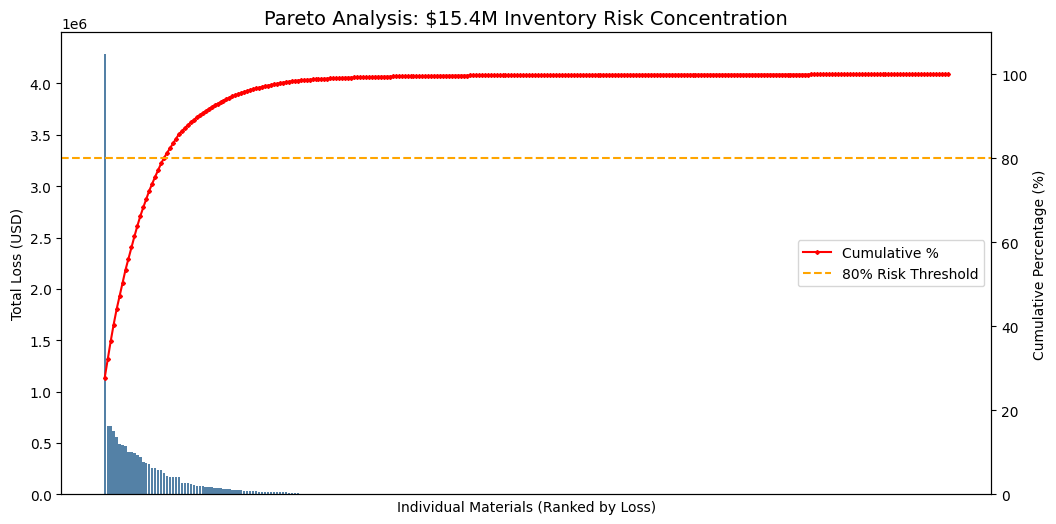

In [106]:
# ---- Pareto Analysis ---- #
# Prove that a few items cause most of the group cost problem

# Prepare Data
pareto_df = MSEG_df.groupby('MSEG_MATERIAL_NUMBER')['GROUP_Cost_USD'].sum().reset_index()
pareto_df = pareto_df.sort_values(by='GROUP_Cost_USD', ascending=False)
pareto_df['cum_sum'] = pareto_df['GROUP_Cost_USD'].cumsum()
pareto_df['cum_perc'] = 100 * pareto_df['cum_sum'] / pareto_df['GROUP_Cost_USD'].sum()

# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.barplot(x=np.arange(len(pareto_df)), y='GROUP_Cost_USD', data=pareto_df, ax=ax1, color='steelblue')
ax1.set_title('Pareto Analysis: $15.4M Inventory Risk Concentration', fontsize=14)
ax1.set_xlabel('Individual Materials (Ranked by Loss)')
ax1.set_ylabel('Total Loss (USD)')
ax1.set_xticks([]) # Hide x-ticks for clarity if many items

# Secondary axis for the cumulative line
ax2 = ax1.twinx()
ax2.plot(np.arange(len(pareto_df)), pareto_df['cum_perc'], color='red', marker="D", ms=2, label='Cumulative %')
ax2.axhline(80, color='orange', linestyle='--', label='80% Risk Threshold')
ax2.set_ylabel('Cumulative Percentage (%)')
ax2.set_ylim(0, 110)

plt.legend(loc='center right')
plt.show()

The Pareto curve reaches the 80% risk threshold (orange dashed line) very rapidly, covering only a small percentage of the total material catalog.
Impact on Modeling: This confirms that a one-size-fits-all forecasting approach is inappropriate. The project will move toward a dual-layer architecture where the Advanced Layer (Anomaly Detection) specifically monitors the high-impact SKUs identified in this tail.

As evidenced by the Pareto Analysis, inventory risk is hyper-concentrated. Standard accuracy metrics would be misleading; therefore, the model is evaluated using WMAE to prioritize the 'Vital Few' SKUs that drive the $15.4M Value-at-Risk.

The first Bar is significantly taller than the rest suggesti g the high-risk items may be statistical outliers. This justifies Issue #4 (Anomily detection) to capture the underlying drivers that standard regression ignores.

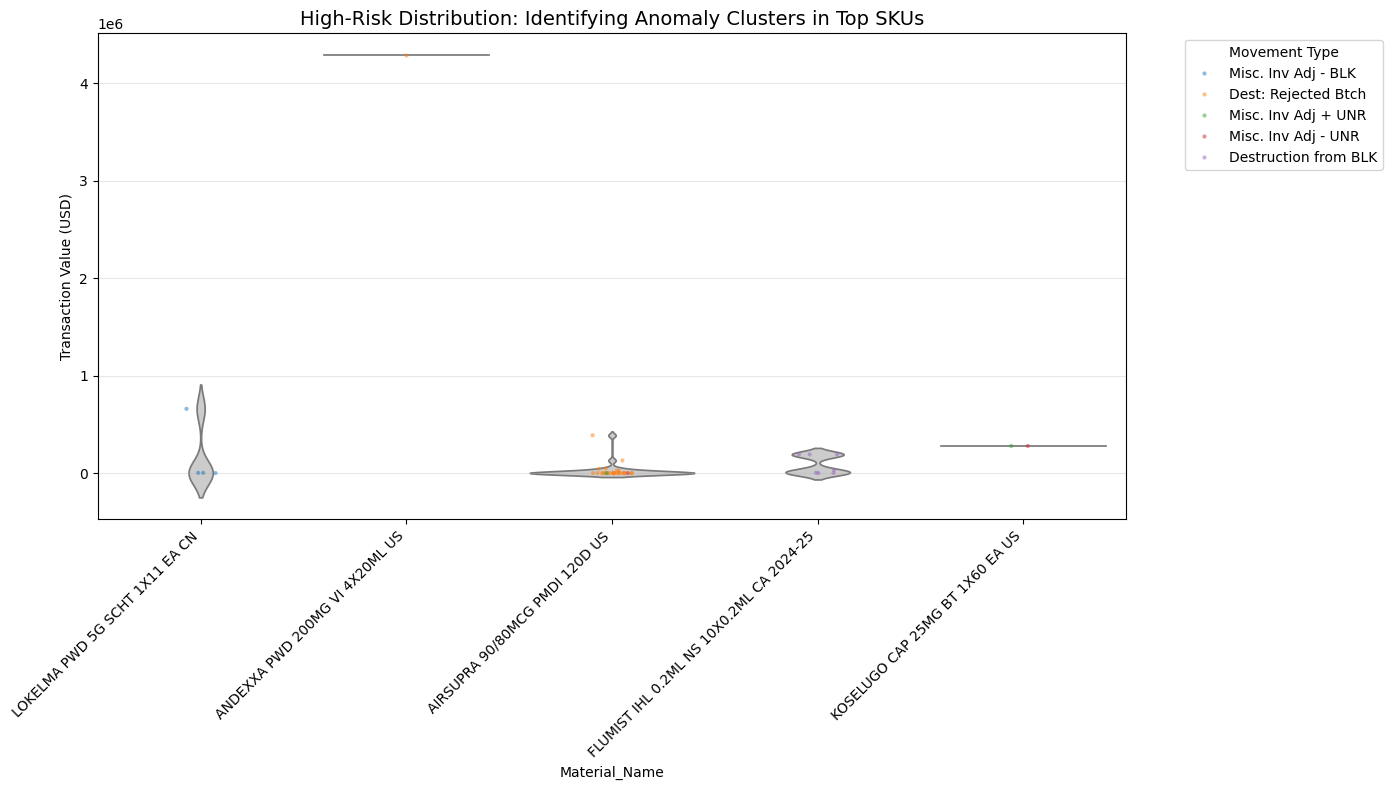

In [107]:
# ----- Using a grouped violin plot to view anomolies ----- #

# 1. Identify the Top 5 High-Risk Materials from the Pareto
top_skus = MSEG_df.groupby('MSEG_MATERIAL_NUMBER')['GROUP_Cost_USD'].sum().sort_values(ascending=False).head(5).index
df_top_skus = MSEG_df[MSEG_df['MSEG_MATERIAL_NUMBER'].isin(top_skus)].copy()

# Map back the names using the Lookup Dictionary from Issue #1
df_top_skus['Material_Name'] = df_top_skus['MSEG_MATERIAL_NUMBER'].map(material_text_lookup)
df_top_skus['Movement_Type'] = df_top_skus['MOVEMENT_TYPE_CODE'].map(movement_lookup)

# 2. Create the Visual (Grouped Violin Plot with Jitter)
plt.figure(figsize=(14, 8))

# Violin plot shows density
sns.violinplot(data=df_top_skus, x='Material_Name', y='GROUP_Cost_USD', inner=None, color=".8", bw_adjust=.5)

# Jitter plot shows individual transaction points (these are the 'anomalies')
sns.stripplot(data=df_top_skus, x='Material_Name', y='GROUP_Cost_USD', size=3, jitter=True, alpha=0.5, hue='Movement_Type')

plt.xticks(rotation=45, ha='right')
plt.title('High-Risk Distribution: Identifying Anomaly Clusters in Top SKUs', fontsize=14)
plt.ylabel('Transaction Value (USD)')
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Movement Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

While a standard Box Plot would identify these as outliers, the Violin Plot with Jitter reveals the density of these events. It shows that high-value losses are not isolated incidents but often occur in 'clusters' related to specific movement types like batch destructions.

To maintain a lean training dataset, textual descriptors were removed from the primary dataframe. However, for the Exploratory Data Analysis (EDA) phase, these descriptors were dynamically re-mapped from the Metadata Lookups.

Andexxa has no violin shape, just a single orange dor above $4M meaning that a single transaction accounts for a massive portion of the risk. A Standard time series model would fail here because there is no trend to follow proving that Anomily detectuion is needed.

Flumist has 2  distinct humpt in the violin menaing there are two different normal behaviours for this drug. The purple dots indicaate 'destruction from BLK' showing that flumist is being actively destroyedin high-value clusters, likely due to seasonal expirey (common for vaccines)

Lokelma and Airsupra have wide base but long 'necks' reaching upwards. this means that there are occasional spikes (blue dots) and are specific data points the Isolation Forest in issue 4 will need to catch



/tmp/ipykernel_12383/2076313515.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  temporal_df = MSEG_df.set_index('DATE')['AMOUNT_IN_USD'].resample('M').sum().reset_index()


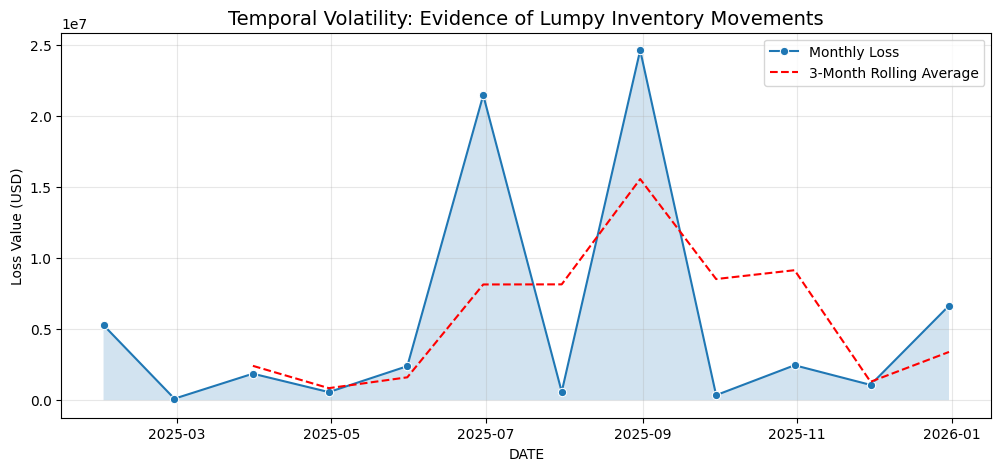

In [108]:
# ----- Temporal Volatility ----- # Evidence of 'lumpy' demand

# 1. Resample data by Month
temporal_df = MSEG_df.set_index('DATE')['AMOUNT_IN_USD'].resample('M').sum().reset_index()

# 2. Plot
plt.figure(figsize=(12, 5))
sns.lineplot(data=temporal_df, x='DATE', y='AMOUNT_IN_USD', marker='o', label='Monthly Loss')
plt.fill_between(temporal_df['DATE'], temporal_df['AMOUNT_IN_USD'], alpha=0.2)

# Rolling average to highlight the "lumpiness"
temporal_df['rolling_avg'] = temporal_df['AMOUNT_IN_USD'].rolling(window=3).mean()
plt.plot(temporal_df['DATE'], temporal_df['rolling_avg'], color='red', linestyle='--', label='3-Month Rolling Average')

plt.title('Temporal Volatility: Evidence of Lumpy Inventory Movements', fontsize=14)
plt.ylabel('Loss Value (USD)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Massive spikes in July 2025 and September 2025 followed by very low months showing that the inventory risk is not steady but explosions of loss at specific intervals. In Pharma this may represent batch expiring or bulk stock cleanouts where entire lots are decomissioned at once

The moving average mimics the blue (mo thly loss) but does not meet the points showing that it will consistently underpredict the spikes so Long term Memory networks are better at 'remembering' the 'state' better than simple averages

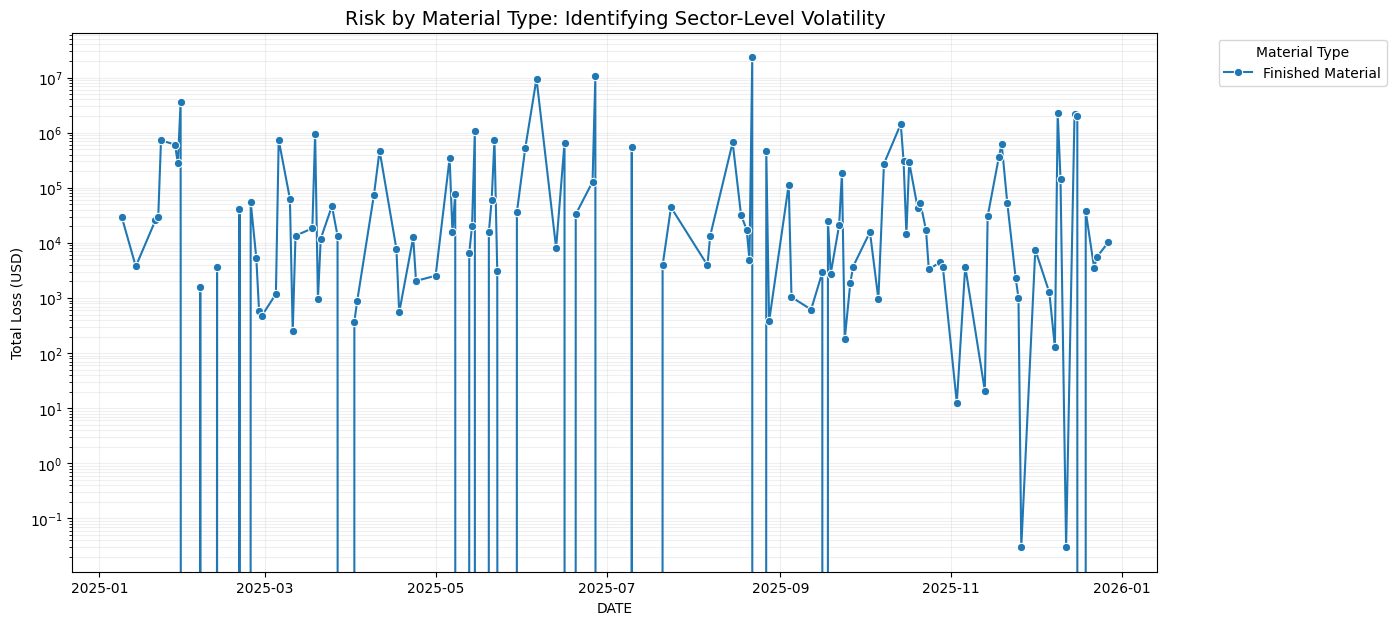

In [109]:
### ------- Aggregate by Material type to see if one material is smoother than the other ------#
# 1. Map the Material Type back
material_to_type_map = MSEG_df[['MSEG_MATERIAL_NUMBER', 'MATERIAL_TYPE_CODE']].drop_duplicates(subset=['MSEG_MATERIAL_NUMBER']).set_index('MSEG_MATERIAL_NUMBER')['MATERIAL_TYPE_CODE']
MSEG_df['Material_Type'] = MSEG_df['MSEG_MATERIAL_NUMBER'].map(material_to_type_map).map(material_type_lookup)

# 2. Aggregate by Month and Material Type
type_agg = MSEG_df.groupby(['DATE', 'Material_Type'])['AMOUNT_IN_USD'].sum().reset_index()

# 3. Visualization
plt.figure(figsize=(14, 7))
sns.lineplot(data=type_agg, x='DATE', y='AMOUNT_IN_USD', hue='Material_Type', marker='o')

plt.title('Risk by Material Type: Identifying Sector-Level Volatility', fontsize=14)
plt.ylabel('Total Loss (USD)')
plt.yscale('log') # Use log scale if one type dwarfs the others
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(title='Material Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

The log-scale reveals losses varying by four orders of magnitude ($10^3$ to $10^7$). This confirms that standard linear regression is unsuitable; XGBoost with Log-Transformation or Huber Loss is required to manage these scale variances without model instability.

The frequent drops to zero identify the data as intermittent. This justifies a Tweedie Distribution approach or a two-stage hurdle model to predict both the occurrence and magnitude of financial shocks.

The lack of clear cyclicality/seasonality suggests the $15M risk is event-driven (e.g., batch expiries) rather than time-driven.

Consequently, categorical features like Movement_Type and Material_Number will be prioritized over temporal features in the modeling phase.

In [113]:
# ---- Feature Creation ----#

# Months To expiry - calculating difference in month
MSEG_df['Months_to_Expiry'] = (MSEG_df['Expiry_Date'] - MSEG_df['DATE']) / pd.Timedelta(days=30)
MSEG_df['Months_to_Expiry'] = MSEG_df['Months_to_Expiry'].round(1)

MSEG_df.head()

,DATE,BRAND_ID,MSEG_MATERIAL_NUMBER,MATERIAL_TYPE_CODE,MOVEMENT_TYPE_CODE,G/L_ACCOUNT,AMOUNT_IN_USD,GROUP_Cost_USD,Expiry_Date,QUANTITY,Material_Type,Months_to_Expiry
1260,2025-12-19,1511,00310027110,ZFIN,988,44890100,0.0,78.672694,2022-02-28,2.0,Finished Material,-46.3
1305,2025-12-19,1511,00310027110,ZFIN,988,44890100,0.0,78.672694,2022-02-28,2.0,Finished Material,-46.3
1249,2025-12-19,1511,00310027210,ZFIN,988,44890100,0.0,78.672694,2022-08-31,2.0,Finished Material,-40.2
354,2025-12-19,1511,00310027460,ZFIN,988,44890100,0.0,78.672694,2022-12-31,3.0,Finished Material,-36.1
1247,2025-12-19,1511,00310027460,ZFIN,988,44890100,0.0,78.672694,2022-01-31,3.0,Finished Material,-47.3


In [115]:
print(f"Feature created. Avg. Months to Expiry: {MSEG_df['Months_to_Expiry'].mean():.1f}")

Feature created. Avg. Months to Expiry: 2.7


In [116]:
# Cost per Unit
"Help model determine between high volume/ low cost and low volume/ high cost loss"

MSEG_df['Cost_per_Unit'] = MSEG_df['AMOUNT_IN_USD'] / MSEG_df['QUANTITY'].replace(0, 1)
MSEG_df.head()


,DATE,BRAND_ID,MSEG_MATERIAL_NUMBER,MATERIAL_TYPE_CODE,MOVEMENT_TYPE_CODE,G/L_ACCOUNT,AMOUNT_IN_USD,GROUP_Cost_USD,Expiry_Date,QUANTITY,Material_Type,Months_to_Expiry,Cost_per_Unit
1260,2025-12-19,1511,00310027110,ZFIN,988,44890100,0.0,78.672694,2022-02-28,2.0,Finished Material,-46.3,0.0
1305,2025-12-19,1511,00310027110,ZFIN,988,44890100,0.0,78.672694,2022-02-28,2.0,Finished Material,-46.3,0.0
1249,2025-12-19,1511,00310027210,ZFIN,988,44890100,0.0,78.672694,2022-08-31,2.0,Finished Material,-40.2,0.0
354,2025-12-19,1511,00310027460,ZFIN,988,44890100,0.0,78.672694,2022-12-31,3.0,Finished Material,-36.1,0.0
1247,2025-12-19,1511,00310027460,ZFIN,988,44890100,0.0,78.672694,2022-01-31,3.0,Finished Material,-47.3,0.0


In [117]:
# Movement_Volatility
MSEG_df = MSEG_df.sort_values(['MSEG_MATERIAL_NUMBER', 'DATE'])
MSEG_df['Movement_Volatility'] = MSEG_df.groupby('MSEG_MATERIAL_NUMBER')['AMOUNT_IN_USD'].transform(
    lambda x: x.rolling(window=3, min_periods=1).std()
).fillna(0)

The above calculates the volatility over a 3-month wondow for each material. Is suitable for XGBoost to catch the Spikes